# H&E image-feature clustering into 26 structures

This second notebook converts the HIPT feature field into coherent
histology-derived spatial structures. It reproduces the H&E branch validated
in `test0730/he_rep1`: 30 initial tissue clusters are consolidated by
feature-based merging, bilateral symmetry, and spatial cleanup into 26 final
regions. These labels are derived from the image only.

**Fixed-seed reproducibility.** This workflow uses seed `0`. Launch Python with `PYTHONHASHSEED` set before kernel startup, then keep the documented input order, package versions and configuration fixed. Discrete labels/pairs are expected to match exactly; CUDA coordinates are compared with the documented numerical tolerance.

## Inputs from notebook 1

Run the image-feature notebook first. Its default outputs are
`tutorials/cross_modality/histology/output/feature_extraction/he.jpg` and
`embeddings-hist-vit.pickle`. During documentation validation, explicit image,
feature, or completed clustering-stage paths can be supplied with environment
variables; public users do not need those variables.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

import spAlignDE

WORKFLOW_SEED = 0
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = Path(
    os.environ.get(
        "SPALIGNDE_HISTOLOGY_DATA_DIR",
        PROJECT_ROOT / "data" / "cross_modality" / "histology" / "mouse_brain",
    )
).expanduser()
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "histology" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
FEATURE_DIR = OUTPUT_DIR / "feature_extraction"
IMAGE_PATH = Path(
    os.environ.get("SPALIGNDE_HISTOLOGY_IMAGE", FEATURE_DIR / "he.jpg")
).expanduser()
FEATURE_PATH = Path(
    os.environ.get(
        "SPALIGNDE_DOCUMENTATION_FEATURE_PATH",
        FEATURE_DIR / "embeddings-hist-vit.pickle",
    )
).expanduser()
CLUSTER_DIR = OUTPUT_DIR / "histology_clustering"

features = spAlignDE.load_histology_features(IMAGE_PATH, FEATURE_PATH)
print("Image:", features.prepared_image_path.name)
print("Feature field:", features.feature_path.name)
print("Feature grid:", features.feature_grid_shape_hw)

Image: he.jpg
Feature field: embeddings-hist-vit.pickle
Feature grid: (1288, 798)


## Cluster, merge, and spatially clean image features

The paper profile uses `k_bg=2`, `k_slide=30`, `k_merge=30`,
`rgb_weight=0.25`, `coordinate_weight=0.05`, `random_state=0`, and a minimum
cleaned component size of 250 feature pixels. At most two symmetry-supported
merges are accepted. Background is encoded as −1 and excluded from alignment.

In [3]:
completed_stage = os.environ.get("SPALIGNDE_DOCUMENTATION_CLUSTER_DIR")
if completed_stage:
    histology = spAlignDE.load_histology_clustering(completed_stage)
    execution_mode = "validated clustering-stage output"
else:
    histology = spAlignDE.cluster_histology_features(
        features,
        CLUSTER_DIR,
        config=spAlignDE.HistologyClusteringConfig(
            random_state=WORKFLOW_SEED,
        ),
    )
    execution_mode = "fresh package clustering"

display(
    pd.Series(
        {
            "mode": execution_mode,
            "feature grid (height, width)": histology.shape,
            "tissue pixels": int(histology.tissue_mask.sum()),
            "initial regions": int(histology.summary["regions"]["labels_full_raw"]),
            "final cleaned regions": histology.n_structures,
        },
        name="value",
    ).to_frame()
)

[Embedding] format: hipt_vit shape: (1288, 798, 579) blocks: {'vit_or_cls': 192, 'uni_or_sub': 384, 'rgb': 3}
[Stage1] source: rgb_proxy
[Stage1-k2] counts: [691660, 270436]
[Stage1-k2] mean_rgb: [0.7005489468574524, 0.9197066426277161]
[Stage1-k2] frac: [0.7189095474879845, 0.2810904525120154]
[Stage1-k2] selected slide_cluster: 0


UD reflection pairs (a,b,iou,dice):
  2 <-> 10 | IoU=0.205 Dice=0.341
  5 <-> 20 | IoU=0.380 Dice=0.551
  6 <-> 27 | IoU=0.339 Dice=0.507
  12 <-> 15 | IoU=0.218 Dice=0.358


,value
mode,fresh package clustering
"feature grid (height, width)","(1288, 798)"
tissue pixels,719657
initial regions,30
final cleaned regions,26


## Quality control: image to final structures

The four panels show the evidence chain used in Supplementary Figure 8:
original H&E morphology, 30 initial feature assignments, symmetry-aware
merging, and the cleaned 26-region structure map. Colors identify image
structures and do not represent cell types or anatomical labels.

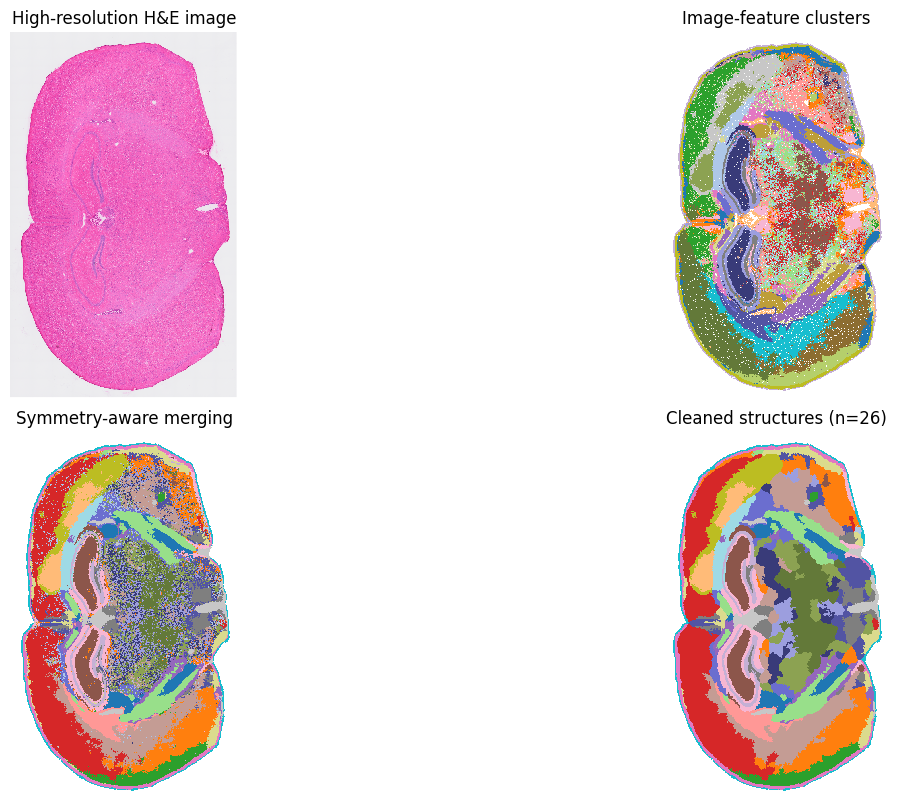

In [4]:
fig, axes = spAlignDE.plot_histology_feature_clusters(
    histology,
    figsize=(13, 8),
)
fig.savefig(FIGURE_DIR / "he_feature_clustering_26_structures.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "he_feature_clustering_26_structures.svg", bbox_inches="tight")
plt.show()

## Output contract and next step

The compact result stores the tissue mask and raw, merged, and cleaned integer
label rasters at feature-grid resolution. Continue with **Xenium Replicate 1
to H&E — pre-alignment and S-LDDMM**. The clustering output is the fixed image
reference for that notebook.